# Example of Python Analysis

## Overview

This notebook provides a step-by-step introduction to **panel data analysis** using Python. Panel data (also called longitudinal data) tracks multiple entities (e.g., countries) over multiple time periods, enabling researchers to control for unobserved heterogeneity that cross-sectional data cannot address.

We use a synthetic dataset inspired by the Barro growth regression literature to demonstrate the complete workflow:

1.  **Data import** — load and inspect the panel structure
2.  **Exploratory data analysis** — descriptive statistics, visualization, and correlation analysis
3.  **Fixed effects regression** — estimate growth equations with progressively richer controls

## 1. Data Import

### Setup

We begin by loading the required libraries and setting the random seed for reproducibility. The plotting theme is configured to produce clean, minimal figures similar to ggplot2’s `theme_minimal`.

In [1]:
# Core data manipulation and visualization libraries
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds for reproducibility across all random number generators
random.seed(42)
np.random.seed(42)

# Configure a minimal plotting theme: no spines, light gridlines, white background
plt.rcParams.update({
    "axes.spines.top": False,       # Remove top border
    "axes.spines.right": False,     # Remove right border
    "axes.spines.left": False,      # Remove left border
    "axes.spines.bottom": False,    # Remove bottom border
    "axes.grid": True,              # Show gridlines
    "axes.grid.axis": "y",          # Gridlines on y-axis only (by default)
    "grid.color": "#E0E0E0",        # Light gray gridlines
    "grid.linewidth": 0.5,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.5,
    "xtick.major.size": 0,          # No tick marks
    "ytick.major.size": 0,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

### Generate Synthetic Panel Data

We create a balanced panel of 40 countries observed at 5-year intervals from 1990 to 2015. The data-generating process (DGP) follows a Barro-style growth equation with known true parameters, allowing us to verify that our estimation methods recover the correct coefficients.

In [2]:
# --- Panel dimensions ---
rng = np.random.default_rng(42)  # Reproducible random number generator
n_countries = 40
years = [1990, 1995, 2000, 2005, 2010, 2015]
n_periods = len(years)
N = n_countries * n_periods       # Total observations: 40 × 6 = 240

# --- Panel identifiers ---
# Each country appears once per period; np.repeat repeats each country ID
# for all periods, np.tile repeats the year sequence for all countries
country_ids = np.repeat(np.arange(1, n_countries + 1), n_periods)
year_ids = np.tile(years, n_countries)

# --- Unobserved heterogeneity (the reason we need fixed effects) ---
# Country FE: permanent differences across countries (e.g., institutions, geography)
country_fe = rng.normal(0, 1.5, n_countries)
# Time FE: global shocks affecting all countries in a given period
time_fe = np.array([-0.5, 0.3, 1.0, -0.2, 0.8, 0.4])

# --- Observable regressors ---
ln_initial_gdp = 7 + rng.normal(0, 1.2, N)     # Log initial GDP per capita
investment     = 15 + rng.normal(0, 5, N)       # Investment share of GDP (%)
schooling      = 6 + rng.normal(0, 3, N)        # Average years of schooling
pop_growth     = 1.5 + rng.normal(0, 0.8, N)    # Population growth rate (%)
trade_openness = 50 + rng.normal(0, 20, N)      # Trade as % of GDP

# --- Data-generating process (DGP) ---
# True model: growth = 2.0 - 0.8*ln_gdp + 0.15*inv + 0.3*school
#                       - 0.5*pop + 0.02*trade + country_FE + time_FE + error
gdp_growth = (
    2.0                                          # Intercept
    - 0.8 * ln_initial_gdp                       # Convergence effect (negative)
    + 0.15 * investment                          # Capital accumulation (positive)
    + 0.3 * schooling                            # Human capital (positive)
    - 0.5 * pop_growth                           # Population dilution (negative)
    + 0.02 * trade_openness                      # Trade benefits (positive)
    + np.repeat(country_fe, n_periods)           # Country-specific intercepts
    + np.tile(time_fe, n_countries)              # Period-specific shocks
    + rng.normal(0, 1.5, N)                      # Idiosyncratic error term
)

# --- Assemble the panel DataFrame ---
panel = pd.DataFrame({
    "country": country_ids,
    "year": year_ids,
    "gdp_growth": np.round(gdp_growth, 2),
    "ln_initial_gdp": np.round(ln_initial_gdp, 2),
    "investment": np.round(investment, 2),
    "schooling": np.round(schooling, 2),
    "pop_growth": np.round(pop_growth, 2),
    "trade_openness": np.round(trade_openness, 2),
})

# Save the dataset so R and Stata notebooks can load it
panel.to_csv("../data/panel_growth.csv", index=False)

print(f"Panel: {n_countries} countries × {n_periods} periods = {N} observations")
print(f"Years: {years[0]}–{years[-1]}")
panel.head()

Panel: 40 countries × 6 periods = 240 observations
Years: 1990–2015

The first rows show the panel structure: each country has one observation per period, with the same set of variables measured at each point in time.

## 2. Exploratory Data Analysis

Before running regressions, it is essential to explore the data. Panel data EDA should pay attention to both the **cross-sectional dimension** (variation across countries) and the **time dimension** (variation within countries over time).

### Descriptive Statistics

A useful way to summarize panel data is to compare descriptive statistics at the beginning and end of the sample period. This reveals how the distribution of each variable has changed over time.

In [3]:
# Define the variables and their human-readable labels
vars_of_interest = [
    "gdp_growth", "ln_initial_gdp", "investment",
    "schooling", "pop_growth", "trade_openness",
]
var_labels = [
    "GDP growth", "Log initial GDP", "Investment",
    "Schooling", "Pop. growth", "Trade openness",
]

# Compute summary statistics for each variable at two points in time
rows = []
for var, label in zip(vars_of_interest, var_labels):
    for yr in [1990, 2015]:
        d = panel.loc[panel["year"] == yr, var]
        rows.append({
            "Variable": f"{label} ({yr})",
            "Mean": round(d.mean(), 2),
            "Median": round(d.median(), 2),
            "SD": round(d.std(), 2),
            "IQR": round(d.quantile(0.75) - d.quantile(0.25), 2),
            "Min": round(d.min(), 2),
            "Max": round(d.max(), 2),
        })

desc = pd.DataFrame(rows)

# Export the table in three formats for use in other documents
desc.to_csv("../tables/tbl-descriptive.csv", index=False)
with open("../tables/tbl-descriptive.md", "w") as f:
    f.write(desc.to_markdown(index=False))
desc.to_latex("../tables/tbl-descriptive.tex", index=False, float_format="%.2f")

# Display the table inline
from IPython.display import Markdown
Markdown(desc.to_markdown(index=False))

### GDP Growth Over Time

Box plots are an effective way to visualize the **distribution** of a variable across groups. Here, each box represents the distribution of GDP growth rates across 40 countries in a given period. The box shows the interquartile range (IQR), the line inside is the median, and the whiskers extend to 1.5 × IQR.

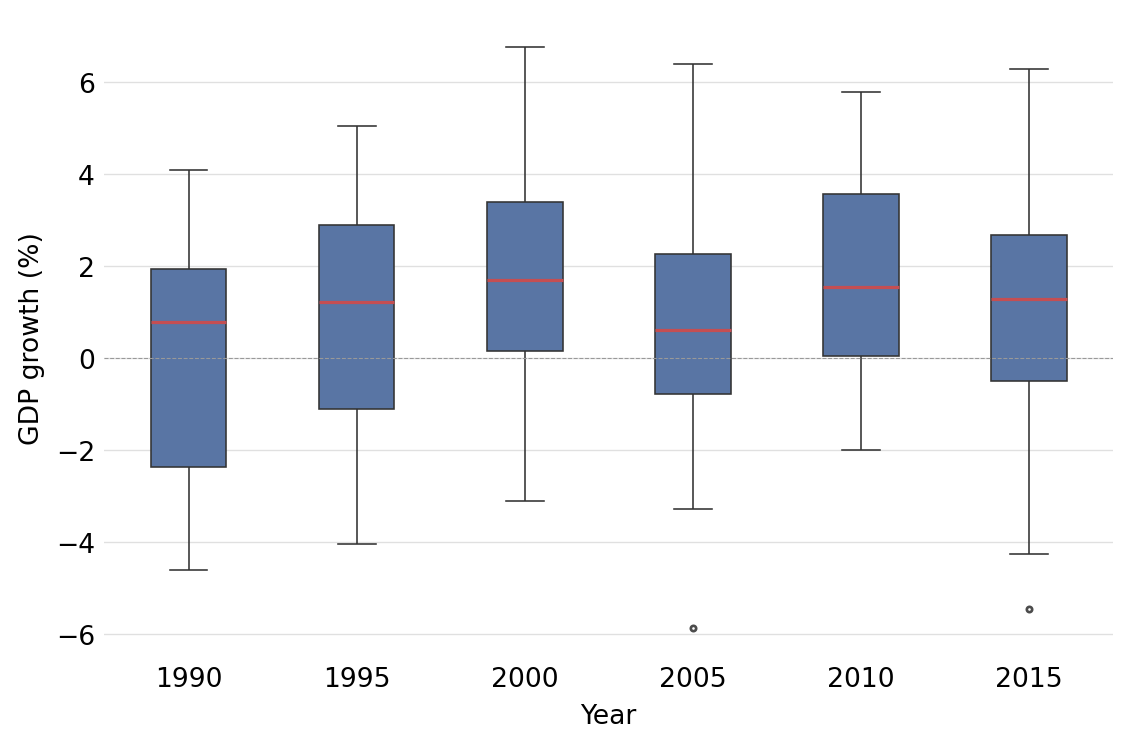

In [4]:
#| label: fig-growth-time
#| fig-cap: Distribution of GDP per capita growth rates by period.
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=panel, x="year", y="gdp_growth",
    color="#4C72B0", width=0.45, fliersize=2,
    boxprops=dict(edgecolor="#333333", linewidth=0.6),
    whiskerprops=dict(color="#333333", linewidth=0.6),
    capprops=dict(color="#333333", linewidth=0.6),
    medianprops=dict(color="#C44E52", linewidth=1.2),
    ax=ax,
)
ax.axhline(y=0, color="#999999", linewidth=0.4, linestyle="--")  # Zero-growth reference
ax.set_xlabel("Year")
ax.set_ylabel("GDP growth (%)")
plt.tight_layout()
fig.savefig("../images/fig-growth-time.png", dpi=300, bbox_inches="tight")
plt.show()

### Convergence: Growth vs. Initial Income

The **convergence hypothesis** is a central prediction of neoclassical growth theory: countries with lower initial income should grow faster, leading to a negative relationship between initial GDP and subsequent growth. The scatter plot below tests this prediction visually, with a linear fit line showing the overall trend.

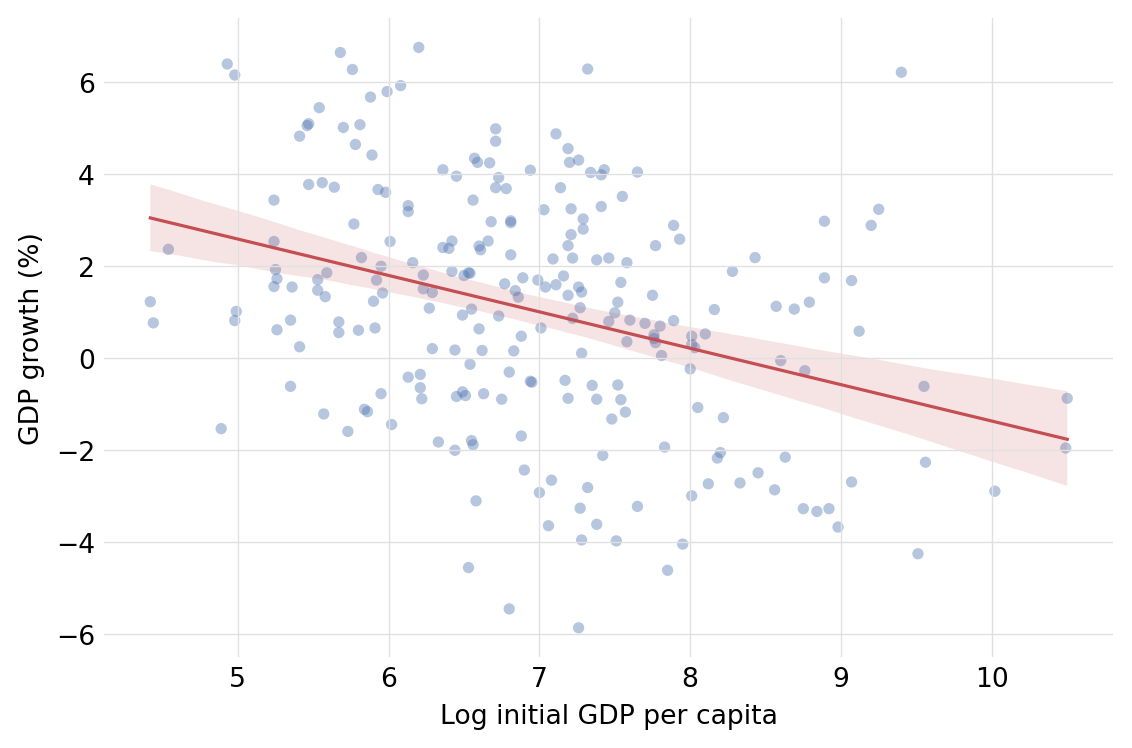

In [5]:
#| label: fig-convergence
#| fig-cap: 'Conditional convergence: GDP growth vs. initial income level.'
fig, ax = plt.subplots(figsize=(6, 4))

# Scatter: each point is one country-period observation
ax.scatter(
    panel["ln_initial_gdp"], panel["gdp_growth"],
    alpha=0.4, s=18, color="#4C72B0", edgecolors="none",
)

# Linear fit: shows the average relationship (convergence slope)
sns.regplot(
    data=panel, x="ln_initial_gdp", y="gdp_growth",
    scatter=False, color="#C44E52", line_kws={"linewidth": 1.2}, ax=ax,
)

ax.grid(axis="x", color="#E0E0E0", linewidth=0.5)  # Add vertical gridlines
ax.set_xlabel("Log initial GDP per capita")
ax.set_ylabel("GDP growth (%)")
plt.tight_layout()
fig.savefig("../images/fig-convergence.png", dpi=300, bbox_inches="tight")
plt.show()

### Correlation Matrix

Before estimating regressions, it is useful to examine the **pairwise correlations** between all variables. This helps identify:

-   Which regressors are most strongly associated with the dependent variable
-   Potential **multicollinearity** issues (highly correlated regressors)

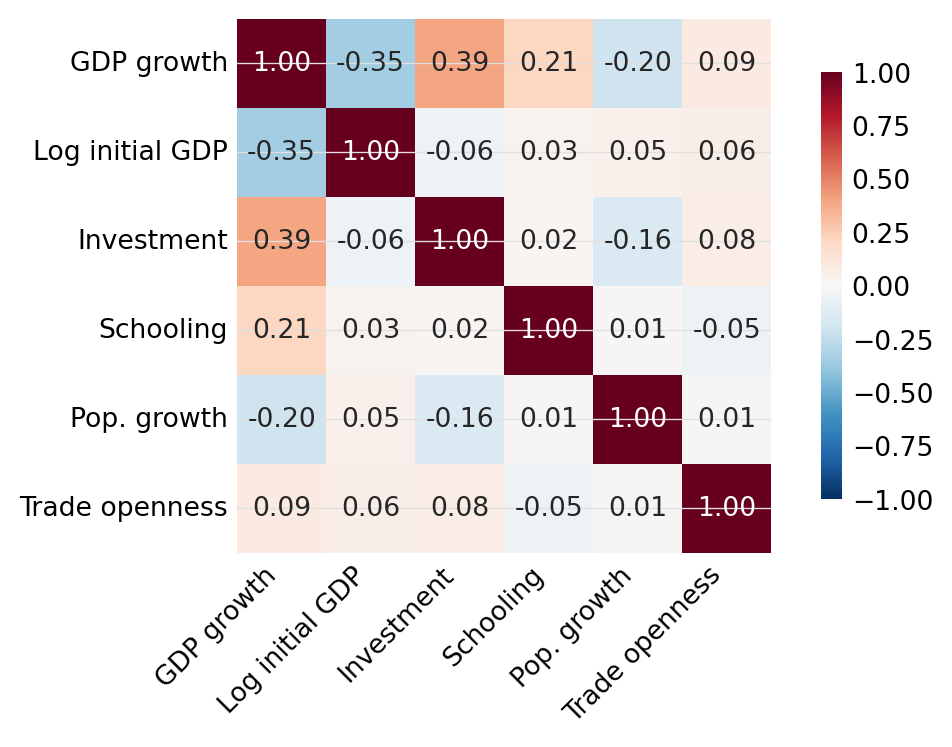

In [6]:
#| label: fig-correlation
#| fig-cap: Pairwise correlations between panel variables.
# Compute the correlation matrix for all numeric variables
corr = panel[vars_of_interest].corr()
labels = var_labels

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    corr, annot=True, fmt=".2f",       # Show correlation values in each cell
    cmap="RdBu_r", center=0,           # Diverging colormap centered at zero
    vmin=-1, vmax=1, square=True,       # Fixed scale from -1 to +1
    xticklabels=labels, yticklabels=labels,
    linewidths=0, cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.tick_params(axis="both", length=0)
ax.set_xticklabels(labels, rotation=45, ha="right")
plt.tight_layout()
fig.savefig("../images/fig-correlation.png", dpi=300, bbox_inches="tight")
plt.show()

## 3. Panel Data Regressions

We now estimate the growth equation using **panel fixed effects** methods. The key idea: by including country fixed effects, we control for all time-invariant differences across countries (institutions, geography, culture). By including time fixed effects, we control for global shocks that affect all countries in a given period (oil crises, financial crises).

We compare four specifications:

1.  **Pooled OLS** — ignores the panel structure (baseline)
2.  **Country FE** — absorbs country-specific intercepts
3.  **Time FE** — absorbs period-specific intercepts
4.  **Two-way FE** — absorbs both country and time effects

In all models, standard errors are **clustered by country** to account for serial correlation within countries over time.

### Estimation

We use the `pyfixest` package, which provides R-style formula syntax. Fixed effects are specified after the `|` operator (e.g., `| country`). When FE are present, `pyfixest` automatically clusters standard errors by the first fixed effect.

In [7]:
import pyfixest as pf

# (1) Pooled OLS — no fixed effects; must specify clustering explicitly
ols = pf.feols(
    "gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness",
    data=panel,
    vcov={"CRV1": "country"},  # Cluster-robust variance by country
)

# (2) Country FE — controls for time-invariant country characteristics
#     The "| country" syntax absorbs country dummies via demeaning
fe_c = pf.feols(
    "gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | country",
    data=panel,  # Auto-clusters by first FE (country)
)

# (3) Time FE — controls for period-specific global shocks
fe_t = pf.feols(
    "gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | year",
    data=panel,
    vcov={"CRV1": "country"},  # Cluster by country (not year)
)

# (4) Two-way FE — controls for both country and time effects
fe_ct = pf.feols(
    "gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | country + year",
    data=panel,  # Auto-clusters by first FE (country)
)

### Build and Export Regression Table

The code below constructs a publication-style regression table with coefficients, standard errors, significance stars, fixed effects indicators, and fit statistics. The table is exported in three formats: Markdown (for the manuscript), LaTeX (for standalone use), and CSV (for data reuse).

In [8]:
# --- Configuration ---
models = [ols, fe_c, fe_t, fe_ct]
model_names = ["OLS", "Country FE", "Time FE", "Two-way FE"]
varnames = ["ln_initial_gdp", "investment", "schooling", "pop_growth", "trade_openness"]
reg_labels = ["Log initial GDP", "Investment", "Schooling", "Pop. growth", "Trade openness"]

def stars(p):
    """Add significance stars based on p-value thresholds."""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

# --- Build coefficient rows ---
# Each variable produces two rows: coefficient (with stars) and SE (in parentheses)
rows = []
for vname, vlabel in zip(varnames, reg_labels):
    coef_row = [vlabel]
    se_row = [""]
    for m in models:
        try:
            c = m.coef()[vname]       # Point estimate
            s = m.se()[vname]         # Standard error
            p = m.pvalue()[vname]     # P-value for significance test
            coef_row.append(f"{c:.3f}{stars(p)}")
            se_row.append(f"({s:.3f})")
        except KeyError:
            coef_row.append("")       # Variable not in model
            se_row.append("")
    rows.append(coef_row)
    rows.append(se_row)

# --- Fixed effects indicators and fit statistics ---
separator = [""] + [""] * 4            # Visual separator between coefficients and metadata
fe_country = ["Country FE", "No", "Yes", "No", "Yes"]
fe_year = ["Year FE", "No", "No", "Yes", "Yes"]
obs_row = ["Observations"] + [str(m._N) for m in models]
r2_row = ["R-squared"] + [f"{m._r2:.3f}" for m in models]

all_rows = rows + [separator, fe_country, fe_year, obs_row, r2_row]

# --- Export as Markdown ---
header = "| | " + " | ".join(f"({i+1}) {n}" for i, n in enumerate(model_names)) + " |"
sep = "|:---|" + "|".join([":---:"] * 4) + "|"
md_lines = [header, sep]
for row in all_rows:
    md_lines.append("| " + " | ".join(row) + " |")
md_out = "\n".join(md_lines)

with open("../tables/tbl-regression.md", "w") as f:
    f.write(md_out)

# --- Export as LaTeX (booktabs format) ---
with open("../tables/tbl-regression.tex", "w") as f:
    f.write("\\begin{tabular}{lcccc}\n\\toprule\n")
    f.write(" & " + " & ".join(f"({i+1}) {n}" for i, n in enumerate(model_names)) + " \\\\\n\\midrule\n")
    for row in all_rows:
        f.write(" & ".join(row) + " \\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# --- Export as CSV ---
csv_rows = [[""] + [f"({i+1}) {n}" for i, n in enumerate(model_names)]]
csv_rows.extend(all_rows)
pd.DataFrame(csv_rows[1:], columns=csv_rows[0]).to_csv(
    "../tables/tbl-regression.csv", index=False
)

# Display the table
Markdown(md_out)

```` markdown
---
title: "Example of Python Analysis"
jupyter: python3
---

## Overview

This notebook provides a step-by-step introduction to **panel data analysis**
using Python. Panel data (also called longitudinal data) tracks multiple
entities (e.g., countries) over multiple time periods, enabling researchers
to control for unobserved heterogeneity that cross-sectional data cannot address.

We use a synthetic dataset inspired by the Barro growth regression literature
to demonstrate the complete workflow:

1. **Data import** — load and inspect the panel structure
2. **Exploratory data analysis** — descriptive statistics, visualization, and correlation analysis
3. **Fixed effects regression** — estimate growth equations with progressively richer controls

## 1. Data Import

### Setup

We begin by loading the required libraries and setting the random seed
for reproducibility. The plotting theme is configured to produce clean,
minimal figures similar to ggplot2's `theme_minimal`.

quarto-executable-code-5450563D

```python
# Core data manipulation and visualization libraries
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set seeds for reproducibility across all random number generators
random.seed(42)
np.random.seed(42)

# Configure a minimal plotting theme: no spines, light gridlines, white background
plt.rcParams.update({
    "axes.spines.top": False,       # Remove top border
    "axes.spines.right": False,     # Remove right border
    "axes.spines.left": False,      # Remove left border
    "axes.spines.bottom": False,    # Remove bottom border
    "axes.grid": True,              # Show gridlines
    "axes.grid.axis": "y",          # Gridlines on y-axis only (by default)
    "grid.color": "#E0E0E0",        # Light gray gridlines
    "grid.linewidth": 0.5,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.5,
    "xtick.major.size": 0,          # No tick marks
    "ytick.major.size": 0,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})
```

### Generate Synthetic Panel Data

We create a balanced panel of 40 countries observed at 5-year intervals
from 1990 to 2015. The data-generating process (DGP) follows a Barro-style
growth equation with known true parameters, allowing us to verify that our
estimation methods recover the correct coefficients.

quarto-executable-code-5450563D

```python
# --- Panel dimensions ---
rng = np.random.default_rng(42)  # Reproducible random number generator
n_countries = 40
years = [1990, 1995, 2000, 2005, 2010, 2015]
n_periods = len(years)
N = n_countries * n_periods       # Total observations: 40 × 6 = 240

# --- Panel identifiers ---
# Each country appears once per period; np.repeat repeats each country ID
# for all periods, np.tile repeats the year sequence for all countries
country_ids = np.repeat(np.arange(1, n_countries + 1), n_periods)
year_ids = np.tile(years, n_countries)

# --- Unobserved heterogeneity (the reason we need fixed effects) ---
# Country FE: permanent differences across countries (e.g., institutions, geography)
country_fe = rng.normal(0, 1.5, n_countries)
# Time FE: global shocks affecting all countries in a given period
time_fe = np.array([-0.5, 0.3, 1.0, -0.2, 0.8, 0.4])

# --- Observable regressors ---
ln_initial_gdp = 7 + rng.normal(0, 1.2, N)     # Log initial GDP per capita
investment     = 15 + rng.normal(0, 5, N)       # Investment share of GDP (%)
schooling      = 6 + rng.normal(0, 3, N)        # Average years of schooling
pop_growth     = 1.5 + rng.normal(0, 0.8, N)    # Population growth rate (%)
trade_openness = 50 + rng.normal(0, 20, N)      # Trade as % of GDP

# --- Data-generating process (DGP) ---
# True model: growth = 2.0 - 0.8*ln_gdp + 0.15*inv + 0.3*school
#                       - 0.5*pop + 0.02*trade + country_FE + time_FE + error
gdp_growth = (
    2.0                                          # Intercept
    - 0.8 * ln_initial_gdp                       # Convergence effect (negative)
    + 0.15 * investment                          # Capital accumulation (positive)
    + 0.3 * schooling                            # Human capital (positive)
    - 0.5 * pop_growth                           # Population dilution (negative)
    + 0.02 * trade_openness                      # Trade benefits (positive)
    + np.repeat(country_fe, n_periods)           # Country-specific intercepts
    + np.tile(time_fe, n_countries)              # Period-specific shocks
    + rng.normal(0, 1.5, N)                      # Idiosyncratic error term
)

# --- Assemble the panel DataFrame ---
panel = pd.DataFrame({
    "country": country_ids,
    "year": year_ids,
    "gdp_growth": np.round(gdp_growth, 2),
    "ln_initial_gdp": np.round(ln_initial_gdp, 2),
    "investment": np.round(investment, 2),
    "schooling": np.round(schooling, 2),
    "pop_growth": np.round(pop_growth, 2),
    "trade_openness": np.round(trade_openness, 2),
})

# Save the dataset so R and Stata notebooks can load it
panel.to_csv("../data/panel_growth.csv", index=False)

print(f"Panel: {n_countries} countries × {n_periods} periods = {N} observations")
print(f"Years: {years[0]}–{years[-1]}")
panel.head()
```

The first rows show the panel structure: each country has one observation
per period, with the same set of variables measured at each point in time.

## 2. Exploratory Data Analysis

Before running regressions, it is essential to explore the data. Panel data
EDA should pay attention to both the **cross-sectional dimension** (variation
across countries) and the **time dimension** (variation within countries over
time).

### Descriptive Statistics

A useful way to summarize panel data is to compare descriptive statistics
at the beginning and end of the sample period. This reveals how the
distribution of each variable has changed over time.

quarto-executable-code-5450563D

```python
# Define the variables and their human-readable labels
vars_of_interest = [
    "gdp_growth", "ln_initial_gdp", "investment",
    "schooling", "pop_growth", "trade_openness",
]
var_labels = [
    "GDP growth", "Log initial GDP", "Investment",
    "Schooling", "Pop. growth", "Trade openness",
]

# Compute summary statistics for each variable at two points in time
rows = []
for var, label in zip(vars_of_interest, var_labels):
    for yr in [1990, 2015]:
        d = panel.loc[panel["year"] == yr, var]
        rows.append({
            "Variable": f"{label} ({yr})",
            "Mean": round(d.mean(), 2),
            "Median": round(d.median(), 2),
            "SD": round(d.std(), 2),
            "IQR": round(d.quantile(0.75) - d.quantile(0.25), 2),
            "Min": round(d.min(), 2),
            "Max": round(d.max(), 2),
        })

desc = pd.DataFrame(rows)

# Export the table in three formats for use in other documents
desc.to_csv("../tables/tbl-descriptive.csv", index=False)
with open("../tables/tbl-descriptive.md", "w") as f:
    f.write(desc.to_markdown(index=False))
desc.to_latex("../tables/tbl-descriptive.tex", index=False, float_format="%.2f")

# Display the table inline
from IPython.display import Markdown
Markdown(desc.to_markdown(index=False))
```

### GDP Growth Over Time

Box plots are an effective way to visualize the **distribution** of a variable
across groups. Here, each box represents the distribution of GDP growth rates
across 40 countries in a given period. The box shows the interquartile range
(IQR), the line inside is the median, and the whiskers extend to 1.5 × IQR.

quarto-executable-code-5450563D

```python
#| label: fig-growth-time
#| fig-cap: "Distribution of GDP per capita growth rates by period."

fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(
    data=panel, x="year", y="gdp_growth",
    color="#4C72B0", width=0.45, fliersize=2,
    boxprops=dict(edgecolor="#333333", linewidth=0.6),
    whiskerprops=dict(color="#333333", linewidth=0.6),
    capprops=dict(color="#333333", linewidth=0.6),
    medianprops=dict(color="#C44E52", linewidth=1.2),
    ax=ax,
)
ax.axhline(y=0, color="#999999", linewidth=0.4, linestyle="--")  # Zero-growth reference
ax.set_xlabel("Year")
ax.set_ylabel("GDP growth (%)")
plt.tight_layout()
fig.savefig("../images/fig-growth-time.png", dpi=300, bbox_inches="tight")
plt.show()
```

### Convergence: Growth vs. Initial Income

The **convergence hypothesis** is a central prediction of neoclassical growth
theory: countries with lower initial income should grow faster, leading to a
negative relationship between initial GDP and subsequent growth. The scatter
plot below tests this prediction visually, with a linear fit line showing
the overall trend.

quarto-executable-code-5450563D

```python
#| label: fig-convergence
#| fig-cap: "Conditional convergence: GDP growth vs. initial income level."

fig, ax = plt.subplots(figsize=(6, 4))

# Scatter: each point is one country-period observation
ax.scatter(
    panel["ln_initial_gdp"], panel["gdp_growth"],
    alpha=0.4, s=18, color="#4C72B0", edgecolors="none",
)

# Linear fit: shows the average relationship (convergence slope)
sns.regplot(
    data=panel, x="ln_initial_gdp", y="gdp_growth",
    scatter=False, color="#C44E52", line_kws={"linewidth": 1.2}, ax=ax,
)

ax.grid(axis="x", color="#E0E0E0", linewidth=0.5)  # Add vertical gridlines
ax.set_xlabel("Log initial GDP per capita")
ax.set_ylabel("GDP growth (%)")
plt.tight_layout()
fig.savefig("../images/fig-convergence.png", dpi=300, bbox_inches="tight")
plt.show()
```

### Correlation Matrix

Before estimating regressions, it is useful to examine the **pairwise
correlations** between all variables. This helps identify:

- Which regressors are most strongly associated with the dependent variable
- Potential **multicollinearity** issues (highly correlated regressors)

quarto-executable-code-5450563D

```python
#| label: fig-correlation
#| fig-cap: "Pairwise correlations between panel variables."

# Compute the correlation matrix for all numeric variables
corr = panel[vars_of_interest].corr()
labels = var_labels

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    corr, annot=True, fmt=".2f",       # Show correlation values in each cell
    cmap="RdBu_r", center=0,           # Diverging colormap centered at zero
    vmin=-1, vmax=1, square=True,       # Fixed scale from -1 to +1
    xticklabels=labels, yticklabels=labels,
    linewidths=0, cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.tick_params(axis="both", length=0)
ax.set_xticklabels(labels, rotation=45, ha="right")
plt.tight_layout()
fig.savefig("../images/fig-correlation.png", dpi=300, bbox_inches="tight")
plt.show()
```

## 3. Panel Data Regressions

We now estimate the growth equation using **panel fixed effects** methods.
The key idea: by including country fixed effects, we control for all
time-invariant differences across countries (institutions, geography,
culture). By including time fixed effects, we control for global shocks
that affect all countries in a given period (oil crises, financial crises).

We compare four specifications:

1. **Pooled OLS** — ignores the panel structure (baseline)
2. **Country FE** — absorbs country-specific intercepts
3. **Time FE** — absorbs period-specific intercepts
4. **Two-way FE** — absorbs both country and time effects

In all models, standard errors are **clustered by country** to account
for serial correlation within countries over time.

### Estimation

We use the `pyfixest` package, which provides R-style formula syntax.
Fixed effects are specified after the `|` operator (e.g., `| country`).
When FE are present, `pyfixest` automatically clusters standard errors
by the first fixed effect.

quarto-executable-code-5450563D

```python
import pyfixest as pf

# (1) Pooled OLS — no fixed effects; must specify clustering explicitly
ols = pf.feols(
    "gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness",
    data=panel,
    vcov={"CRV1": "country"},  # Cluster-robust variance by country
)

# (2) Country FE — controls for time-invariant country characteristics
#     The "| country" syntax absorbs country dummies via demeaning
fe_c = pf.feols(
    "gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | country",
    data=panel,  # Auto-clusters by first FE (country)
)

# (3) Time FE — controls for period-specific global shocks
fe_t = pf.feols(
    "gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | year",
    data=panel,
    vcov={"CRV1": "country"},  # Cluster by country (not year)
)

# (4) Two-way FE — controls for both country and time effects
fe_ct = pf.feols(
    "gdp_growth ~ ln_initial_gdp + investment + schooling + pop_growth + trade_openness | country + year",
    data=panel,  # Auto-clusters by first FE (country)
)
```

### Build and Export Regression Table

The code below constructs a publication-style regression table with
coefficients, standard errors, significance stars, fixed effects indicators,
and fit statistics. The table is exported in three formats: Markdown
(for the manuscript), LaTeX (for standalone use), and CSV (for data reuse).

quarto-executable-code-5450563D

```python
# --- Configuration ---
models = [ols, fe_c, fe_t, fe_ct]
model_names = ["OLS", "Country FE", "Time FE", "Two-way FE"]
varnames = ["ln_initial_gdp", "investment", "schooling", "pop_growth", "trade_openness"]
reg_labels = ["Log initial GDP", "Investment", "Schooling", "Pop. growth", "Trade openness"]

def stars(p):
    """Add significance stars based on p-value thresholds."""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

# --- Build coefficient rows ---
# Each variable produces two rows: coefficient (with stars) and SE (in parentheses)
rows = []
for vname, vlabel in zip(varnames, reg_labels):
    coef_row = [vlabel]
    se_row = [""]
    for m in models:
        try:
            c = m.coef()[vname]       # Point estimate
            s = m.se()[vname]         # Standard error
            p = m.pvalue()[vname]     # P-value for significance test
            coef_row.append(f"{c:.3f}{stars(p)}")
            se_row.append(f"({s:.3f})")
        except KeyError:
            coef_row.append("")       # Variable not in model
            se_row.append("")
    rows.append(coef_row)
    rows.append(se_row)

# --- Fixed effects indicators and fit statistics ---
separator = [""] + [""] * 4            # Visual separator between coefficients and metadata
fe_country = ["Country FE", "No", "Yes", "No", "Yes"]
fe_year = ["Year FE", "No", "No", "Yes", "Yes"]
obs_row = ["Observations"] + [str(m._N) for m in models]
r2_row = ["R-squared"] + [f"{m._r2:.3f}" for m in models]

all_rows = rows + [separator, fe_country, fe_year, obs_row, r2_row]

# --- Export as Markdown ---
header = "| | " + " | ".join(f"({i+1}) {n}" for i, n in enumerate(model_names)) + " |"
sep = "|:---|" + "|".join([":---:"] * 4) + "|"
md_lines = [header, sep]
for row in all_rows:
    md_lines.append("| " + " | ".join(row) + " |")
md_out = "\n".join(md_lines)

with open("../tables/tbl-regression.md", "w") as f:
    f.write(md_out)

# --- Export as LaTeX (booktabs format) ---
with open("../tables/tbl-regression.tex", "w") as f:
    f.write("\\begin{tabular}{lcccc}\n\\toprule\n")
    f.write(" & " + " & ".join(f"({i+1}) {n}" for i, n in enumerate(model_names)) + " \\\\\n\\midrule\n")
    for row in all_rows:
        f.write(" & ".join(row) + " \\\\\n")
    f.write("\\bottomrule\n\\end{tabular}\n")

# --- Export as CSV ---
csv_rows = [[""] + [f"({i+1}) {n}" for i, n in enumerate(model_names)]]
csv_rows.extend(all_rows)
pd.DataFrame(csv_rows[1:], columns=csv_rows[0]).to_csv(
    "../tables/tbl-regression.csv", index=False
)

# Display the table
Markdown(md_out)
```
````